In [1]:
# Import required libraries (CUDA version)
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import machine learning libraries
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (roc_auc_score, roc_curve, accuracy_score, 
                           confusion_matrix, precision_score, recall_score, 
                           f1_score)


In [2]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv('../Sino_CT.csv')

# Convert the 'embedding' column from string to a list
df['embedding'] = df['embedding'].apply(eval)

# Map the 'label' column to 0 for abnormal ('0,1') and 1 for normal ('1,0')
df['label'] = df['label'].apply(lambda x: 1 if x == '1,0' else 0)

# Define the target column
target_column = 'label'

# Load the embeddings and target values
X = np.array(df['embedding'].tolist(), dtype=np.float32)
y = df[target_column].values.astype(np.float32)

# Reshape y to be (n_samples, 1) for consistency with the model output
y = y.reshape(-1, 1)

# Split the data with 80 percent for training and 20 percent for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print("Data loaded and preprocessed successfully.")
print("X_train_tensor shape:", X_train_tensor.shape)
print("y_train_tensor shape:", y_train_tensor.shape)

Data loaded and preprocessed successfully.
X_train_tensor shape: torch.Size([5464, 1408])
y_train_tensor shape: torch.Size([5464, 1])


In [3]:
import torch
import torch.nn as nn

class TensorFlowToPyTorchModel(nn.Module):
    def __init__(self, input_features=1408):
        super(TensorFlowToPyTorchModel, self).__init__()
        
        # Define the sequential layers
        self.model = nn.Sequential(
            # First block: 1408 → 1536
            nn.Linear(input_features, 1536),
            nn.BatchNorm1d(1536),
            nn.ReLU(),
            nn.Dropout(p=0.4372695307748339),
            
            # Second block: 1536 → 896
            nn.Linear(1536, 896),
            nn.BatchNorm1d(896),
            nn.ReLU(),
            nn.Dropout(p=0.3417774049274107),
            
            # Third block: 896 → 128
            nn.Linear(896, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(p=0.24257773824341827),
            
            # Output layer: 128 → 1 (no activation, BN, or dropout)
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.model(x)

# Instantiate the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = TensorFlowToPyTorchModel(input_features=1408)
model = model.to(device)

In [4]:
# Define loss function and optimizer
criterion = nn.BCEWithLogitsLoss()  # Combines Sigmoid + BCE for numerical stability
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Optional: Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', 
                                                   factor=0.5, patience=5)

# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in train_loader:
        # Move data to device
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass and optimize
        loss.backward()
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item() * inputs.size(0)
        predictions = torch.sigmoid(outputs) > 0.5
        correct += (predictions == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# Validation function
def validate_epoch(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            probs = torch.sigmoid(outputs)
            predictions = probs > 0.5
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            
            # Store for AUC calculation
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    epoch_auc = roc_auc_score(all_labels, all_probs)
    
    return epoch_loss, epoch_acc, epoch_auc, all_labels, all_probs

# Training loop
num_epochs = 100
best_val_auc = 0.0
best_model_weights = None
train_losses = []
val_losses = []
train_accs = []
val_accs = []
val_aucs = []

print("Starting training...")
for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc, val_auc, _, _ = validate_epoch(model, test_loader, criterion, device)
    
    # Store metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    val_aucs.append(val_auc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Save best model
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_model_weights = model.state_dict().copy()
        print(f"✓ New best model at epoch {epoch+1}")
    
    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val AUC: {val_auc:.4f}")

# Load best model
model.load_state_dict(best_model_weights)
print(f"\nTraining complete! Best validation AUC: {best_val_auc:.4f}")

# Save the model
torch.save({
    'epoch': num_epochs,
    'model_state_dict': best_model_weights,
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_auc': best_val_auc,
}, 'best_model_checkpoint.pth')
print("Model saved as 'best_model_checkpoint.pth'")

Starting training...
✓ New best model at epoch 1
✓ New best model at epoch 1
✓ New best model at epoch 2
✓ New best model at epoch 2
✓ New best model at epoch 9
✓ New best model at epoch 9
Epoch [10/100] Train Loss: 0.4595, Train Acc: 0.7776 | Val Loss: 0.4989, Val Acc: 0.7518, Val AUC: 0.8345
Epoch [10/100] Train Loss: 0.4595, Train Acc: 0.7776 | Val Loss: 0.4989, Val Acc: 0.7518, Val AUC: 0.8345
✓ New best model at epoch 17
✓ New best model at epoch 17
Epoch [20/100] Train Loss: 0.4329, Train Acc: 0.7914 | Val Loss: 0.5022, Val Acc: 0.7555, Val AUC: 0.8360
Epoch [20/100] Train Loss: 0.4329, Train Acc: 0.7914 | Val Loss: 0.5022, Val Acc: 0.7555, Val AUC: 0.8360
✓ New best model at epoch 21
✓ New best model at epoch 21
✓ New best model at epoch 23
✓ New best model at epoch 23
✓ New best model at epoch 24
✓ New best model at epoch 24
Epoch [30/100] Train Loss: 0.4033, Train Acc: 0.8108 | Val Loss: 0.5166, Val Acc: 0.7599, Val AUC: 0.8379
Epoch [30/100] Train Loss: 0.4033, Train Acc: 0.8


Final Test Results:
Test Loss: 0.5234
Test Accuracy: 0.7526
Test AUC: 0.8355
Test Precision: 0.7404
Test Recall: 0.7689
Test F1 Score: 0.7544


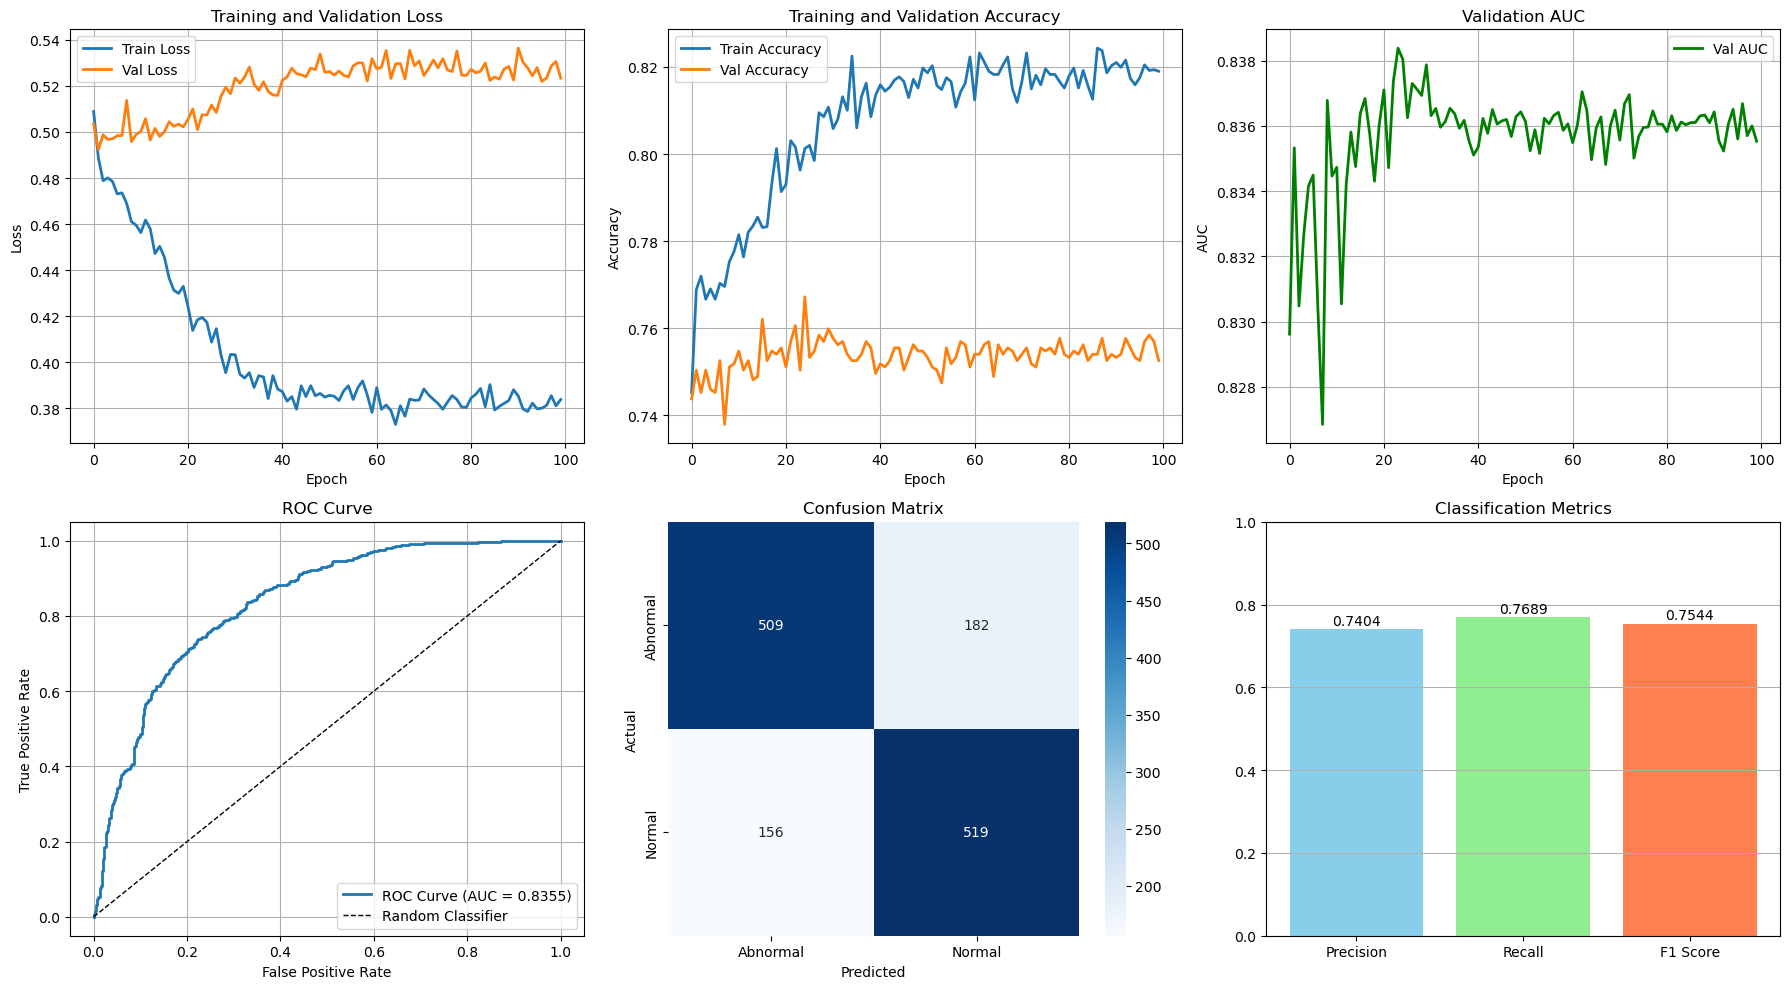

In [5]:
model.eval()
test_loss, test_acc, test_auc, test_labels, test_probs = validate_epoch(
    model, test_loader, criterion, device
)

# Calculate additional metrics
test_preds = (np.array(test_probs) > 0.5).astype(int)
test_precision = precision_score(test_labels, test_preds)
test_recall = recall_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds)

print(f"\nFinal Test Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

# Plot training curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
axes[0, 0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0, 0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(train_accs, label='Train Accuracy', linewidth=2)
axes[0, 1].plot(val_accs, label='Val Accuracy', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# AUC
axes[0, 2].plot(val_aucs, label='Val AUC', linewidth=2, color='green')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('AUC')
axes[0, 2].set_title('Validation AUC')
axes[0, 2].legend()
axes[0, 2].grid(True)

# ROC Curve
fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
axes[1, 0].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {test_auc:.4f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Confusion Matrix
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Abnormal', 'Normal'],
            yticklabels=['Abnormal', 'Normal'],
            ax=axes[1, 1])
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')
axes[1, 1].set_title('Confusion Matrix')

# Additional Metrics Bar Plot
metrics = ['Precision', 'Recall', 'F1 Score']
values = [test_precision, test_recall, test_f1]
axes[1, 2].bar(metrics, values, color=['skyblue', 'lightgreen', 'coral'])
axes[1, 2].set_ylim(0, 1)
axes[1, 2].set_title('Classification Metrics')
for i, v in enumerate(values):
    axes[1, 2].text(i, v + 0.01, f'{v:.4f}', ha='center')
axes[1, 2].grid(True, axis='y')

plt.tight_layout()
plt.show()